In [ ]:

import pandas as pd
import numpy as np 

In [2]:
import joblib
X = joblib.load("C:\Materials and it's Mechanical Properties\Data\X_features.pkl")
y = joblib.load("C:\Materials and it's Mechanical Properties\Data\y_energy_per_atom.pkl")

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\kisho\AppData\Local\Temp\ipykernel_1568\1949697301.py:2: SyntaxWarning: invalid escape sequence '\M'
  X = joblib.load("C:\Materials and it's Mechanical Properties\Data\X_features.pkl")
C:\Users\kisho\AppData\Local\Temp\ipykernel_1568\1949697301.py:3: SyntaxWarning: invalid escape sequence '\M'
  y = joblib.load("C:\Materials and it's Mechanical Properties\Data\y_energy_per_atom.pkl")


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [5]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

In [8]:
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

rmse, r2, mae


(np.float64(0.191954766405149),
 0.9634061796493263,
 np.float64(0.0841188658203818))

In [9]:
train_pred = model.predict(X_train)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, y_pred))


Train R²: 0.9685580694997077
Test R² : 0.9634061796493263


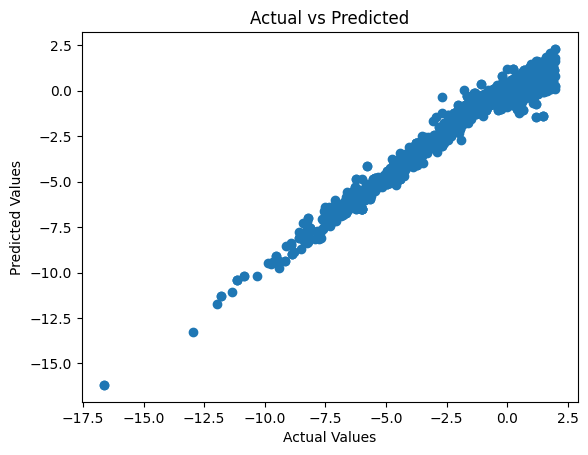

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values",)
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()


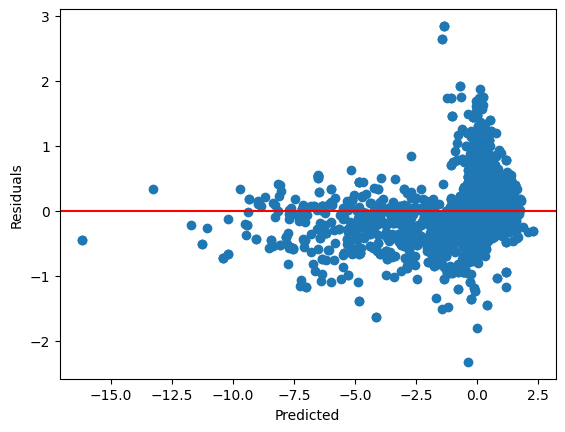

In [11]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


In [12]:
import pickle 
import os 

folder_path = "C:\Materials and it's Mechanical Properties\Model"
filename = "energy_per_atom.pkl"
full_path = os.path.join(folder_path, filename)

with open(full_path, 'wb') as file:
    pickle.dump(model, file, protocol=pickle.HIGHEST_PROTOCOL)

<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
C:\Users\kisho\AppData\Local\Temp\ipykernel_1568\1093187065.py:4: SyntaxWarning: invalid escape sequence '\M'
  folder_path = "C:\Materials and it's Mechanical Properties\Model"
